In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset_path = "/content/drive/MyDrive/TrashType_Image_Dataset"

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 480 images belonging to 6 classes.
Found 120 images belonging to 6 classes.


In [ ]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))

base_model.trainable = False  # freeze base model

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.4938 - loss: 1.2731 - val_accuracy: 0.6417 - val_loss: 0.9341
Epoch 2/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.8000 - loss: 0.5439 - val_accuracy: 0.6583 - val_loss: 0.8641
Epoch 3/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9125 - loss: 0.3036 - val_accuracy: 0.6667 - val_loss: 0.9134
Epoch 4/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.9771 - loss: 0.1807 - val_accuracy: 0.6500 - val_loss: 0.8797
Epoch 5/5
15/15 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.9958 - loss: 0.1122 - val_accuracy: 0.6750 - val_loss: 0.9295


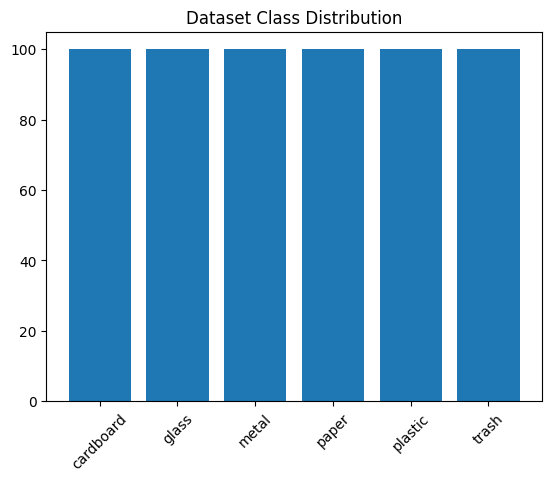

In [ ]:
import matplotlib.pyplot as plt

labels = list(train_data.class_indices.keys())
counts = [0]*len(labels)

# Count images per class
import os
for i, label in enumerate(labels):
    counts[i] = len(os.listdir(os.path.join(dataset_path, label)))

plt.bar(labels, counts)
plt.title("Dataset Class Distribution")
plt.xticks(rotation=45)
plt.show()

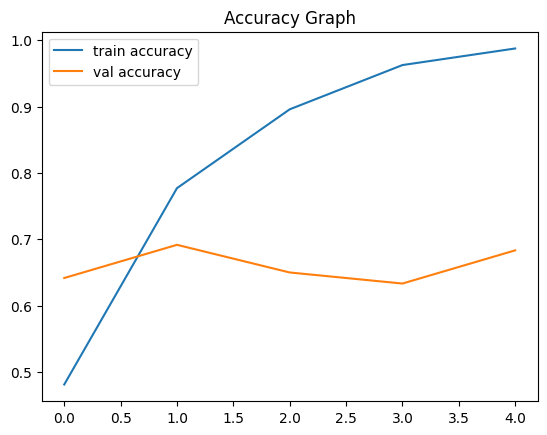

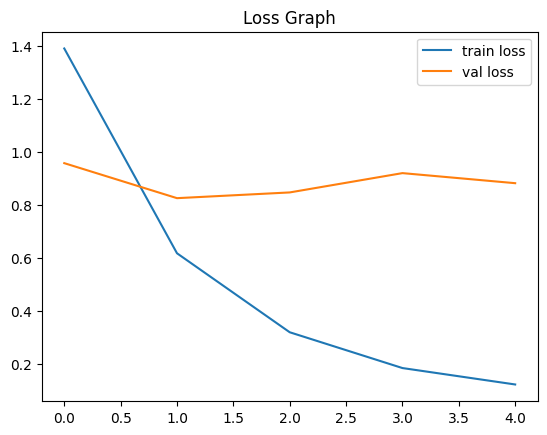

In [ ]:
# Accuracy graph
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

# Loss graph
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

In [ ]:
model.save("waste_model.h5")

In [ ]:
from sklearn.metrics import classification_report
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf # Import tensorflow for model loading

# Re-define val_data and its dependencies for robustness
dataset_path = "/content/drive/MyDrive/TrashType_Image_Dataset"
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Load the saved model to ensure it's available
loaded_model = tf.keras.models.load_model("waste_model.h5")

# Get true labels from validation data
val_labels = []
val_predictions = []

# Reset the generator to ensure predictions are made on the full validation set
val_data.reset()

for i in range(len(val_data)):
    images, labels = val_data[i]
    val_labels.extend(np.argmax(labels, axis=1))
    predictions = loaded_model.predict(images, verbose=0) # Use the loaded model
    val_predictions.extend(np.argmax(predictions, axis=1))

# Convert to numpy arrays
val_labels = np.array(val_labels)
val_predictions = np.array(val_predictions)

# Get class names from the generator
class_names = list(val_data.class_indices.keys())

# Generate classification report
report = classification_report(val_labels, val_predictions, target_names=class_names, zero_division=0)
print("\nClassification Report:\n", report)

Found 480 images belonging to 6 classes.
Found 120 images belonging to 6 classes.



Classification Report:
               precision    recall  f1-score   support

   cardboard       0.91      1.00      0.95        20
       glass       0.53      0.50      0.51        20
       metal       0.76      0.65      0.70        20
       paper       0.79      0.75      0.77        20
     plastic       0.47      0.70      0.56        20
       trash       0.77      0.50      0.61        20

    accuracy                           0.68       120
   macro avg       0.70      0.68      0.68       120
weighted avg       0.70      0.68      0.68       120



In [ ]:

from google.colab import files
from IPython.display import Javascript, display
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# -----------------------------
# CAMERA FUNCTION
# -----------------------------
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = '📸 Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')

    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])

    with open(filename, 'wb') as f:
        f.write(binary)

    return filename


# -----------------------------
# USER CHOICE
# -----------------------------
choice = input("Choose option:\n1 - Upload Image\n2 - Capture Image\nEnter 1 or 2: ")

if choice == "1":
    uploaded = files.upload()
    file_names = list(uploaded.keys())

elif choice == "2":
    file_path = take_photo()
    file_names = [file_path]

else:
    print("Invalid choice")
    file_names = []


# -----------------------------
# CLASS LABELS
# -----------------------------
classes = list(train_data.class_indices.keys())


# -----------------------------
# DISPOSAL GUIDE
# -----------------------------
disposal_guide = {
    "cardboard": "♻️ Flatten and recycle in cardboard bin.",
    "glass": "🍾 Rinse and recycle safely.",
    "metal": "🔩 Clean and recycle (cans, tins).",
    "paper": "📄 Keep dry and recycle.",
    "plastic": "🧴 Rinse and recycle if possible.",
    "trash": "🚫 Dispose in general waste."
}

# -----------------------------
# ECO TIPS
# -----------------------------
eco_tips = {
    "cardboard": "🌱 Saves trees and reduces landfill.",
    "glass": "🌍 Recyclable infinitely.",
    "metal": "⚡ Saves energy when recycled.",
    "paper": "📘 Reduces deforestation.",
    "plastic": "🚯 Avoid single-use plastics.",
    "trash": "⚠️ Reduce waste generation."
}

# -----------------------------
# CATEGORY GROUP
# -----------------------------
category_group = {
    "cardboard": "Recyclable ♻️",
    "glass": "Recyclable ♻️",
    "metal": "Recyclable ♻️",
    "paper": "Recyclable ♻️",
    "plastic": "Recyclable ♻️",
    "trash": "Non-Recyclable 🚫"
}

# -----------------------------
# IMPACT SCORE
# -----------------------------
impact_score = {
    "cardboard": "Low Impact 🌱",
    "glass": "Medium Impact 🌍",
    "metal": "Medium Impact 🌍",
    "paper": "Low Impact 🌱",
    "plastic": "High Impact ⚠️",
    "trash": "Very High Impact 🚨"
}


# -----------------------------
# PREDICTION LOOP
# -----------------------------
for file_name in file_names:

    img = image.load_img(file_name, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    class_index = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    result = classes[class_index].lower()

    # Extra Features
    disposal = disposal_guide.get(result, "N/A")
    tip = eco_tips.get(result, "")
    group = category_group.get(result, "Unknown")
    impact = impact_score.get(result, "")

    # Top 3 Predictions
    top3 = np.argsort(prediction[0])[-3:][::-1]

    # Display Image
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{result} ({confidence:.2f}%)")
    plt.show()

    # Output
    print("\n🔎 Waste Type:", result.capitalize())
    print("📊 Confidence: {:.2f}%".format(confidence))

    print("\n🧠 Category Group:", group)
    print("📉 Impact Level:", impact)

    print("\n♻️ Disposal Suggestion:")
    print(disposal)

    print("\n🌍 Eco Tip:")
    print(tip)

    print("\n🔝 Top 3 Predictions:")
    for i in top3:
        print(f"{classes[i]} → {prediction[0][i]*100:.2f}%")

    # Save History
    with open("history.txt", "a") as f:
        f.write(f"{result} - {confidence:.2f}%\n")